# GC bias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import seaborn.objects as so

custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(
    context="notebook",
    style="ticks", 
    palette="colorblind",
    font_scale=1.1,
    rc=custom_params
)

# For SVG output
plt.rcParams['svg.fonttype'] = 'none'
figdir = Path("../figures/svg")

In [3]:
samples = pd.read_csv("../sample_info.tsv", sep="\t") 
samples["Type"] = samples["IsSingleCell"].replace({True: "Single cell", False: "Bulk"})
human_samples = samples.query("Genome == 'Human'")
human_samples

,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
0,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
1,P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#02),Single cell
2,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell
3,P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#04),Single cell
4,P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#05),Single cell
5,P33410_1006,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
7,P33410_1008,Q_A3_cell_07,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#07),Single cell
8,P33410_1009,Q_B3_cell_08,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#08),Single cell
9,P33410_1010,Q_C3_cell_09,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#09),Single cell
10,P33410_1011,Q_D3_cell_10,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#10),Single cell


In [4]:
data = []
basedir = Path("../analysis/downsample_40M/downstream/picard")
assert basedir.exists()
for file in basedir.rglob("*.gc_bias_metrics.txt"):
    sample = file.stem.split(".")[0]
    d = pd.read_csv(file, sep="\t", skiprows=6)
    d["NGI ID"] = sample

    data.append(d)

data = pd.concat(data).reset_index(drop=True)
data = data.merge(samples, on="NGI ID")
data.head()

,ACCUMULATION_LEVEL,READS_USED,GC,WINDOWS,READ_STARTS,MEAN_BASE_QUALITY,NORMALIZED_COVERAGE,ERROR_BAR_WIDTH,SAMPLE,LIBRARY,READ_GROUP,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
0,All Reads,ALL,0,133402,520,17,0.140437,0.006159,NaN,NaN,NaN,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell
1,All Reads,ALL,1,96778,179,16,0.066637,0.004981,NaN,NaN,NaN,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell
2,All Reads,ALL,2,112145,270,17,0.086741,0.005279,NaN,NaN,NaN,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell
3,All Reads,ALL,3,142995,459,18,0.115646,0.005398,NaN,NaN,NaN,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell
4,All Reads,ALL,4,154320,581,18,0.135642,0.005627,NaN,NaN,NaN,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell


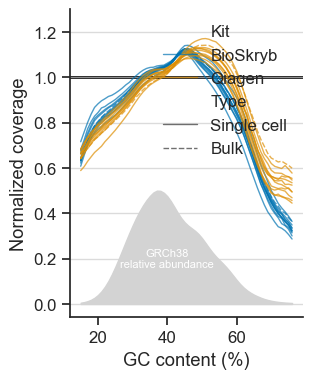

In [8]:
d = data.query("WINDOWS > 1000_000")
fig, ax = plt.subplots(figsize=(3, 4))
ax = sns.lineplot(
    data=d, 
    x="GC", 
    y="NORMALIZED_COVERAGE", 
    hue="Kit",
    hue_order=sorted(data["Kit"].unique()),
    style="Type",
    units="NGI ID",
    estimator=None,
    lw=1,
    alpha=0.7,
    ax=ax,
    )

# Add heatmap with relative bin abundance in GRCh38
_ = ax.annotate("GRCh38\nrelative abundance", xy=(40, 0.2), ha="center", va="center", 
                color="white", fontsize=8)
for _, d in d.groupby(["User ID"]):
    break
y = (d["WINDOWS"] / d["WINDOWS"].max()).values  / 2 
x = d["GC"]
ax.fill_between(x, y, color="lightgrey")

plt.legend(frameon=False, framealpha=0, loc="upper right")
sns.move_legend(ax, loc="upper right")
ax.set_ylim(top=1.3)
ax.set_ylabel("Normalized coverage")
ax.set_xlabel("GC content (%)")

ax.grid(axis="y",  alpha=0.7)
ax.axhline(1, ls="-", color="black", lw=2, zorder=-1)

plt.savefig(figdir / "gc_bias.svg", bbox_inches="tight")

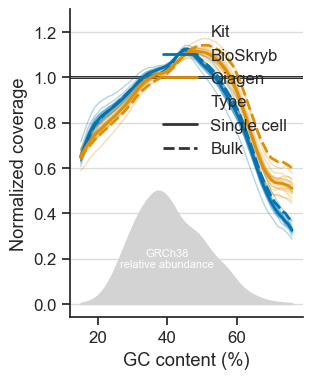

In [7]:
d = data.query("WINDOWS > 1000_000")
fig, ax = plt.subplots(figsize=(3, 4))
ax = sns.lineplot(
    data=d, 
    x="GC", 
    y="NORMALIZED_COVERAGE", 
    hue="Kit",
    hue_order=sorted(data["Kit"].unique()),
    style="Type",
    units="NGI ID",
    estimator=None,
    lw=1,
    alpha=0.3,
    ax=ax,
    legend=False
    )

ax = sns.lineplot(
    data=d, 
    x="GC", 
    y="NORMALIZED_COVERAGE", 
    hue="Kit",
    hue_order=sorted(data["Kit"].unique()),
    style="Type",
    #units="NGI ID",
    #estimator=None,
    lw=2,
    ax=ax,
    )

# Add heatmap with relative bin abundance in GRCh38
_ = ax.annotate("GRCh38\nrelative abundance", xy=(40, 0.2), ha="center", va="center", color="white", fontsize=8)
for _, d in d.groupby(["User ID"]):
    break
y = (d["WINDOWS"] / d["WINDOWS"].max()).values  / 2 
x = d["GC"]
ax.fill_between(x, y, color="lightgrey")

plt.legend(frameon=False, framealpha=0, loc="upper right")
sns.move_legend(ax, loc="upper right")
ax.set_ylim(top=1.3)
ax.set_ylabel("Normalized coverage")
ax.set_xlabel("GC content (%)")

ax.grid(axis="y",  alpha=0.7)
ax.axhline(1, ls="-", color="black", lw=2, zorder=-1)

plt.savefig(figdir / "gc_bias.svg", bbox_inches="tight")

In [28]:
list(d.groupby(["User ID"]))[0][1]

,ACCUMULATION_LEVEL,READS_USED,GC,WINDOWS,READ_STARTS,MEAN_BASE_QUALITY,NORMALIZED_COVERAGE,ERROR_BAR_WIDTH,SAMPLE,LIBRARY,READ_GROUP,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
1227,All Reads,ALL,15,1285786,22798,21,0.631723,0.004184,NaN,NaN,NaN,P33410_1013,B_A3_cell_01,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#01),Single cell
1228,All Reads,ALL,16,1924728,36943,22,0.683851,0.003558,NaN,NaN,NaN,P33410_1013,B_A3_cell_01,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#01),Single cell
1229,All Reads,ALL,17,2891023,59006,22,0.727183,0.002994,NaN,NaN,NaN,P33410_1013,B_A3_cell_01,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#01),Single cell
1230,All Reads,ALL,18,4335741,92485,22,0.759988,0.002499,NaN,NaN,NaN,P33410_1013,B_A3_cell_01,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#01),Single cell
1231,All Reads,ALL,19,6401990,141038,22,0.784910,0.002090,NaN,NaN,NaN,P33410_1013,B_A3_cell_01,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#01),Single cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1284,All Reads,ALL,72,2131665,24216,22,0.404746,0.002601,NaN,NaN,NaN,P33410_1013,B_A3_cell_01,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#01),Single cell
1285,All Reads,ALL,73,1739975,18541,22,0.379655,0.002788,NaN,NaN,NaN,P33410_1013,B_A3_cell_01,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#01),Single cell
1286,All Reads,ALL,74,1435643,14672,22,0.364118,0.003006,NaN,NaN,NaN,P33410_1013,B_A3_cell_01,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#01),Single cell
1287,All Reads,ALL,75,1208249,11860,21,0.349725,0.003211,NaN,NaN,NaN,P33410_1013,B_A3_cell_01,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#01),Single cell


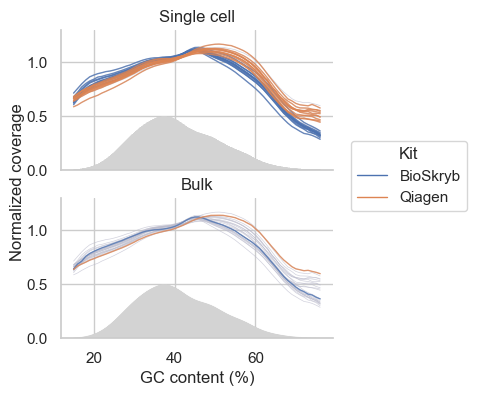

In [14]:
d = data.query("WINDOWS > 1000_000").copy()
ab = d.copy()
ab["NORMALIZED_COVERAGE"] = ab["WINDOWS"] / ab["WINDOWS"].max() * 0.5
fig = plt.figure(figsize=(3.5, 4))
fig.text(0.0, 0.5, "Normalized coverage", ha="center", va="center", rotation=90, fontsize=12)
p = (
    so.Plot(d, x="GC", y="NORMALIZED_COVERAGE", color="Kit", group="NGI ID")
    .facet(
        row="Type",
    )
    .add(so.Lines(color="#bbca", linewidth=0.5), col=None, row=None, group="NGI ID")
    .add(so.Lines(linewidth=1, alpha=0.8), color="Kit", group="NGI ID")
    .add(so.Area(color="lightgrey", fill=True, edgewidth=0, alpha=1), data=ab, legend=False)
    .limit(y=(0,1.3))
    .scale(
        color=so.Nominal(order=["BioSkryb", "Qiagen"]),
    )
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .label(
        x="GC content (%)",
        y="",
    )
    .on(fig)
    .save(figdir / "gc_bias_split.svg", dpi=300, bbox_inches="tight", transparent=True)
)
